### Amazon Non-Mattress Category 세분화 하기 - 머신러닝 모델 적용

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [4]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [5]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [11]:
sql = f"""
SELECT * FROM wook.tmp_rf_amz_stck_asin_pdt_nonmattress
"""

df = bqclient.query(sql).to_dataframe()

In [13]:
pd.set_option("display.max_columns", None)

In [15]:
print(df)

                                                   title  \
0      Magnussen Raelynn King Panel Bed in Weathered ...   
1      Upholstered Daybed and Trundle, Velvet Modern ...   
2      King Bed Frame with 50.7'' High Wingback Headb...   
3      Emurphybed Paradiseo Murphy Cabinet Chest Bed ...   
4      Full Size Murphy Bed Chest, Murphy Cabinet Bed...   
...                                                  ...   
73290  Linique Full Size Castle Shaped Bunk Bed with ...   
73291  Linique Queen Size Upholstered Bed Frame with ...   
73292  Linique Full Size Loft Bed with Ladder, Shelve...   
73293  Benjara BM295825 Lilya Traditional Bead Moldin...   
73294  Bestar Nebula 59W Full Murphy Bed in Bark Gray...   

                            title_excluding_variant_name  \
0                                                   None   
1                                                   None   
2      King Bed Frame with 50.7'' High Wingback Headb...   
3                                      

In [17]:
df['category5'].unique()

array(['Beds', 'Bed Frames', 'Box Springs'], dtype=object)

In [36]:
df['category6'].unique()

array([None], dtype=object)

In [19]:
df.groupby('category5')['asin'].nunique()

category5
Bed Frames     47800
Beds           24151
Box Springs     1344
Name: asin, dtype: int64

### 1. Clustering 모델 적용하기

In [49]:
import re
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [53]:
# =========================
# 0) 공통 유틸
# =========================
def normalize_keywords_list(x):
    """keywords_list가 문자열 형태의 리스트여도 안전하게 리스트로 복구"""
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            val = literal_eval(x)
            if isinstance(val, list):
                return val
        except Exception:
            pass
        return [t.strip() for t in x.split(",") if t.strip()]
    return []

def build_text(row):
    title = (row.get("title") or "").lower()
    desc = (row.get("description") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""

    text = " ".join([title, kw, desc])
    text = re.sub(r"[^a-z0-9\s\-\+']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def subset_by_category(df, main_cat="Beds"):
    return df.loc[df["category5"] == main_cat].copy()

def top_terms_per_cluster(kmeans_model, vectorizer, topn=15):
    centroids = kmeans_model.cluster_centers_
    terms = np.array(vectorizer.get_feature_names_out())
    top_terms = {}
    for cid in range(centroids.shape[0]):
        idx = centroids[cid].argsort()[::-1][:topn]
        top_terms[cid] = terms[idx].tolist()
    return top_terms

# 클러스터명 규칙 (이전 코드와 동일/확장 가능)
NAME_RULES = [
    (["bunk", "ladder"], "Bunk Beds"),
    (["loft", "desk"], "Loft Beds"),
    (["daybed", "day bed"], "Daybeds"),
    (["canopy"], "Canopy Beds"),
    (["platform", "slat"], "Platform Beds"),
    (["storage", "drawer", "trundle"], "Storage Beds"),
    (["upholstered", "velvet", "fabric", "linen"], "Upholstered Beds"),
    (["metal", "steel", "iron"], "Metal Beds"),
    (["wood", "wooden", "pine", "oak", "acacia", "walnut", "solid"], "Wood Beds"),
    (["kids", "toddler"], "Kids Beds"),
    (["murphy", "cabinet"], "Other: murphy, cabinet, murphy bed"),
]

def name_cluster(term_list):
    joined = " ".join(term_list)
    for keys, label in NAME_RULES:
        if any(k in joined for k in keys):
            return label
    return "Other: " + ", ".join(term_list[:3])

# =========================
# 1) 카테고리별 클러스터링 함수
# =========================
def cluster_one_category(df_cat, candidate_k=(8,10,12,15,18), tfidf=None):
    df_cat = df_cat[df_cat["title"].notna()].copy()
    df_cat["text"] = df_cat.apply(build_text, axis=1)

    # 벡터화
    if tfidf is None:
        tfidf = TfidfVectorizer(
            max_features=30000,
            ngram_range=(1,2),
            min_df=5,
            stop_words="english",
        )
        X = tfidf.fit_transform(df_cat["text"])
        fitted_vectorizer = tfidf
    else:
        X = tfidf.transform(df_cat["text"])
        fitted_vectorizer = tfidf

    # k 선택(빠르게 하고 싶으면 고정 k 사용)
    sil_scores = {}
    for k in candidate_k:
        km_tmp = KMeans(n_clusters=k, n_init="auto", random_state=42)
        labels_tmp = km_tmp.fit_predict(X)
        if X.shape[0] > 20000:
            idx = np.random.choice(X.shape[0], min(20000, X.shape[0]), replace=False)
            score = silhouette_score(X[idx], labels_tmp[idx])
        else:
            score = silhouette_score(X, labels_tmp)
        sil_scores[k] = score
    best_k = max(sil_scores, key=sil_scores.get)

    # 최종 적합
    kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
    df_cat["cluster_id"] = kmeans.fit_predict(X)

    # 클러스터 대표 키워드 → 이름
    cluster_terms = top_terms_per_cluster(kmeans, fitted_vectorizer, topn=20)
    cluster_name_map = {cid: name_cluster(cluster_terms[cid]) for cid in cluster_terms}
    df_cat["cluster_name"] = df_cat["cluster_id"].map(cluster_name_map)

    return df_cat, fitted_vectorizer, kmeans, cluster_terms, sil_scores

# =========================
# 2) Platform Beds 내부 세분화
# =========================
def classify_platform_bed_row(row):
    """
    Platform Beds 내부를 Metal / Wood / Upholstered / Storage / Other로 세분화.
    title, keywords_list, specifications_flat(재질/수납 단서) 활용.
    """
    title = (row.get("title") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    specs = (row.get("specifications_flat") or "").lower()

    text_all = " ".join([title, kw, specs])

    # Storage 먼저(가장 명확한 의도)
    if any(w in text_all for w in ["storage", "drawer", "drawers", "trundle", "lift up", "gas lift", "underbed", "under bed"]):
        return "Storage Platform Beds"

    # 재질 기반
    if any(w in text_all for w in ["metal", "steel", "iron"]):
        return "Metal Platform Beds"
    if any(w in text_all for w in ["upholstered", "velvet", "linen", "fabric", "faux leather", "leather"]):
        return "Upholstered Platform Beds"
    if any(w in text_all for w in ["wood", "wooden", "pine", "oak", "acacia", "walnut", "mdf", "plywood", "solid wood", "solid"]):
        return "Wood Platform Beds"

    return "Other Platform Beds"

def refine_platform_beds(df_all):
    """
    cluster_name이 'Platform Beds' 인 행들만 세분화.
    세분화 라벨은 최종 SubCategory로 사용.
    기타 클러스터는 기존 cluster_name 사용.
    """
    df_all = df_all.copy()
    is_platform = df_all["cluster_name"].eq("Platform Beds")

    df_all.loc[is_platform, "SubCategory"] = df_all.loc[is_platform].apply(classify_platform_bed_row, axis=1)
    df_all.loc[~is_platform, "SubCategory"] = df_all.loc[~is_platform, "cluster_name"]
    return df_all

# =========================
# 3) 실행 (Beds / Bed Frames → 병합 → 세분화)
# =========================
# 예: df 원본에 category5, title, keywords_list, description, specifications_flat 등이 있다고 가정
# df = ...

# Beds
df_beds = subset_by_category(df, "Beds")
df_beds, vec_beds, km_beds, terms_beds, sil_beds = cluster_one_category(df_beds)

# Bed Frames
df_frames = subset_by_category(df, "Bed Frames")
# (벡터라이저를 공유하지 않고 각 도메인 단독 피쳐로 학습하는 쪽이 일반적으로 성능/해석이 낫습니다)
df_frames, vec_frames, km_frames, terms_frames, sil_frames = cluster_one_category(df_frames)

# 병합
df_clustered = pd.concat([df_beds, df_frames], ignore_index=True)

# Platform Beds 내부 세분화 적용
df_final = refine_platform_beds(df_clustered)

# =========================
# 4) 결과 확인
# =========================
# (1) 전체 요약: SubCategory 별 개수
summary = (
    df_final.groupby(["category5", "SubCategory"])
            .agg(n_items=("asin", "count"))
            .sort_values("n_items", ascending=False)
)
print(summary.head(30))

# (2) Platform Beds 내부 세분화 결과
platform_summary = (
    df_final.loc[df_final["SubCategory"].str.contains("Platform Beds", na=False)]
             .groupby("SubCategory")
             .size()
             .sort_values(ascending=False)
)
print("\n[Platform Beds breakdown]")
print(platform_summary)

# 필요시 저장
# df_final.to_parquet("subcat_with_platform_refined.parquet", index=False)

                                               n_items
category5  SubCategory                                
Bed Frames Storage Platform Beds                 15086
           Upholstered Platform Beds              8246
           Metal Platform Beds                    7779
Beds       Daybeds                                6887
           Bunk Beds                              6316
Bed Frames Storage Beds                           4989
Beds       Storage Platform Beds                  3247
Bed Frames Daybeds                                2934
           Wood Platform Beds                     2714
Beds       Upholstered Platform Beds              2708
Bed Frames Other: murphy, cabinet, murphy bed     1695
           Bunk Beds                              1494
Beds       Other: murphy, cabinet, murphy bed     1364
           Wood Platform Beds                     1347
           Metal Platform Beds                    1004
Bed Frames Kids Beds                               865
          

In [55]:

# =========================
# 0) 공통 유틸
# =========================
def normalize_keywords_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            val = literal_eval(x)
            if isinstance(val, list):
                return val
        except Exception:
            pass
        return [t.strip() for t in x.split(",") if t.strip()]
    return []

def build_text(row):
    title = (row.get("title") or "").lower()
    desc = (row.get("description") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    text = " ".join([title, kw, desc])
    text = re.sub(r"[^a-z0-9\s\-\+']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def subset_by_category(df, main_cat="Beds"):
    return df.loc[df["category5"] == main_cat].copy()

def top_terms_per_cluster(kmeans_model, vectorizer, topn=15):
    centroids = kmeans_model.cluster_centers_
    terms = np.array(vectorizer.get_feature_names_out())
    top_terms = {}
    for cid in range(centroids.shape[0]):
        idx = centroids[cid].argsort()[::-1][:topn]
        top_terms[cid] = terms[idx].tolist()
    return top_terms

# 클러스터명 규칙
NAME_RULES = [
    (["bunk", "ladder"], "Bunk Beds"),
    (["loft", "desk"], "Loft Beds"),
    (["daybed", "day bed"], "Daybeds"),
    (["canopy"], "Canopy Beds"),
    (["platform", "slat"], "Platform Beds"),
    (["storage", "drawer", "trundle"], "Storage Beds"),
    (["upholstered", "velvet", "fabric", "linen"], "Upholstered Beds"),
    (["metal", "steel", "iron"], "Metal Beds"),
    (["wood", "wooden", "pine", "oak", "acacia", "walnut", "mdf", "plywood", "solid"], "Wood Beds"),
    (["kids", "toddler"], "Kids Beds"),
    (["murphy", "cabinet"], "Other: murphy, cabinet, murphy bed"),
]

def name_cluster(term_list):
    joined = " ".join(term_list)
    for keys, label in NAME_RULES:
        if any(k in joined for k in keys):
            return label
    return "Other: " + ", ".join(term_list[:3])

# =========================
# 1) 카테고리별 클러스터링
# =========================
def cluster_one_category(df_cat, candidate_k=(8,10,12,15,18), tfidf=None):
    df_cat = df_cat[df_cat["title"].notna()].copy()
    df_cat["text"] = df_cat.apply(build_text, axis=1)

    if tfidf is None:
        tfidf = TfidfVectorizer(
            max_features=30000,
            ngram_range=(1,2),
            min_df=5,
            stop_words="english",
        )
        X = tfidf.fit_transform(df_cat["text"])
        fitted_vectorizer = tfidf
    else:
        X = tfidf.transform(df_cat["text"])
        fitted_vectorizer = tfidf

    # k 선택(샘플링 실루엣)
    sil_scores = {}
    for k in candidate_k:
        km_tmp = KMeans(n_clusters=k, n_init="auto", random_state=42)
        labels_tmp = km_tmp.fit_predict(X)
        if X.shape[0] > 20000:
            idx = np.random.choice(X.shape[0], min(20000, X.shape[0]), replace=False)
            score = silhouette_score(X[idx], labels_tmp[idx])
        else:
            score = silhouette_score(X, labels_tmp)
        sil_scores[k] = score
    best_k = max(sil_scores, key=sil_scores.get)

    kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
    df_cat["cluster_id"] = kmeans.fit_predict(X)

    cluster_terms = top_terms_per_cluster(kmeans, fitted_vectorizer, topn=20)
    cluster_name_map = {cid: name_cluster(cluster_terms[cid]) for cid in cluster_terms}
    df_cat["cluster_name"] = df_cat["cluster_id"].map(cluster_name_map)

    return df_cat, fitted_vectorizer, kmeans, cluster_terms, sil_scores

# =========================
# 2) Platform Beds: 재질 먼저 분류 + Storage는 속성 태깅
# =========================
def detect_storage(row):
    title = (row.get("title") or "").lower()
    specs = (row.get("specifications_flat") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    text = " ".join([title, kw, specs])
    storage_terms = ["storage", "drawer", "drawers", "trundle", "underbed", "under bed", "lift up", "gas lift", "lift-up"]
    return any(w in text for w in storage_terms)

def classify_platform_material(row):
    # 재질 우선(단일 레이블)
    title = (row.get("title") or "").lower()
    specs = (row.get("specifications_flat") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    text = " ".join([title, kw, specs])

    if any(w in text for w in ["upholstered", "velvet", "linen", "fabric", "faux leather", "leather"]):
        return "Upholstered Platform Beds"
    if any(w in text for w in ["metal", "steel", "iron"]):
        return "Metal Platform Beds"
    if any(w in text for w in ["wood", "wooden", "pine", "oak", "acacia", "walnut", "mdf", "plywood", "solid wood", "solid"]):
        return "Wood Platform Beds"
    return "Other Platform Beds"

def refine_platform_beds_material_first(df_all):
    df_all = df_all.copy()
    is_platform = df_all["cluster_name"].eq("Platform Beds")

    # 재질 기반 단일 레이블
    df_all.loc[is_platform, "SubCategory"] = df_all.loc[is_platform].apply(classify_platform_material, axis=1)
    # Storage 속성 태그(Boolean)
    df_all.loc[is_platform, "has_storage"] = df_all.loc[is_platform].apply(detect_storage, axis=1)

    # Platform이 아닌 경우는 원래 클러스터명 사용, has_storage는 False로
    df_all.loc[~is_platform, "SubCategory"] = df_all.loc[~is_platform, "cluster_name"]
    df_all.loc[~is_platform, "has_storage"] = False

    # (선택) 속성을 문자열로도 보유
    df_all["Attributes"] = np.where(df_all["has_storage"], "Storage", "")
    return df_all

# =========================
# 3) 실행 (Beds / Bed Frames → 병합 → 재질 우선 + Storage 태깅)
# =========================
# df = ...  # 원본 DataFrame (category5, title, keywords_list, description, specifications_flat 등 포함)

# Beds
df_beds = subset_by_category(df, "Beds")
df_beds, vec_beds, km_beds, terms_beds, sil_beds = cluster_one_category(df_beds)

# Bed Frames
df_frames = subset_by_category(df, "Bed Frames")
df_frames, vec_frames, km_frames, terms_frames, sil_frames = cluster_one_category(df_frames)

# 병합
df_clustered = pd.concat([df_beds, df_frames], ignore_index=True)

# Platform Beds: 재질 기반 SubCategory + Storage 태깅
df_final = refine_platform_beds_material_first(df_clustered)

# =========================
# 4) 결과 확인
# =========================
# (1) 전체 요약: SubCategory x has_storage
summary = (
    df_final.groupby(["category5", "SubCategory", "has_storage"])
            .agg(n_items=("asin", "count"))
            .sort_values("n_items", ascending=False)
)
print(summary.head(30))

# (2) Platform Beds만 재질-속성 분해 요약
plat = df_final[df_final["SubCategory"].str.contains("Platform Beds", na=False)]
plat_summary = (
    plat.groupby(["SubCategory", "has_storage"])
        .size()
        .unstack("has_storage", fill_value=0)
        .rename(columns={False:"no_storage", True:"has_storage"})
        .sort_values("has_storage", ascending=False)
)
print("\n[Platform Beds breakdown by material + storage]")
print(plat_summary)


                                                           n_items
category5  SubCategory                        has_storage         
Bed Frames Upholstered Platform Beds          False          11122
                                              True            7832
Beds       Daybeds                            False           6887
           Bunk Beds                          False           6316
Bed Frames Storage Beds                       False           4989
           Metal Platform Beds                False           4903
                                              True            3922
Beds       Upholstered Platform Beds          False           3219
Bed Frames Daybeds                            False           2934
           Wood Platform Beds                 True            2904
                                              False           2714
           Other: murphy, cabinet, murphy bed False           1695
           Bunk Beds                          False           

In [58]:
summary.to_csv('summary_0819.csv')

In [60]:

# =========================
# 0) 공통 유틸
# =========================
def normalize_keywords_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            val = literal_eval(x)
            if isinstance(val, list):
                return val
        except Exception:
            pass
        return [t.strip() for t in x.split(",") if t.strip()]
    return []

def build_text(row):
    title = (row.get("title") or "").lower()
    desc = (row.get("description") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    text = " ".join([title, kw, desc])
    text = re.sub(r"[^a-z0-9\s\-\+']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def text_all_fields(row):
    title = (row.get("title") or "").lower()
    specs = (row.get("specifications_flat") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    return " ".join([title, kw, specs])

def subset_by_category(df, main_cat="Beds"):
    return df.loc[df["category5"] == main_cat].copy()

def top_terms_per_cluster(kmeans_model, vectorizer, topn=15):
    centroids = kmeans_model.cluster_centers_
    terms = np.array(vectorizer.get_feature_names_out())
    top_terms = {}
    for cid in range(centroids.shape[0]):
        idx = centroids[cid].argsort()[::-1][:topn]
        top_terms[cid] = terms[idx].tolist()
    return top_terms

# =========================
# 1) 클러스터명 규칙 (초기 네이밍용)
#   - Adjustable/Storage 신호를 넣어 초기에 어느정도 분리되도록 보강
# =========================
NAME_RULES = [
    # Adjustable 키워드 (초기 클러스터 이름에서도 어느정도 반영)
    (["adjustable base", "adjustable bed", "adjustable frame", "zero gravity", "massage"], "Adjustable Beds"),
    (["bunk", "ladder"], "Bunk Beds"),
    (["loft", "desk"], "Loft Beds"),
    (["daybed", "day bed"], "Daybeds"),
    (["canopy"], "Canopy Beds"),
    # Platform의 일반 신호
    (["platform", "slat"], "Platform Beds"),
    # Storage 독립 신호 (platform 유무와 무관)
    (["storage", "drawer", "drawers", "trundle", "underbed", "under bed", "lift up", "lift-up", "hydraulic", "ottoman"], "Storage Beds"),
    # 재질 일반 신호
    (["upholstered", "velvet", "fabric", "linen"], "Upholstered Beds"),
    (["metal", "steel", "iron"], "Metal Beds"),
    (["wood", "wooden", "pine", "oak", "acacia", "walnut", "mdf", "plywood", "solid"], "Wood Beds"),
    (["kids", "toddler"], "Kids Beds"),
    (["murphy", "cabinet"], "Other: murphy, cabinet, murphy bed"),
]

def name_cluster(term_list):
    joined = " ".join(term_list)
    for keys, label in NAME_RULES:
        if any(k in joined for k in keys):
            return label
    return "Other: " + ", ".join(term_list[:3])

# =========================
# 2) 카테고리별 클러스터링
# =========================
def cluster_one_category(df_cat, candidate_k=(8,10,12,15,18), tfidf=None):
    df_cat = df_cat[df_cat["title"].notna()].copy()
    df_cat["text"] = df_cat.apply(build_text, axis=1)

    if tfidf is None:
        tfidf = TfidfVectorizer(
            max_features=30000,
            ngram_range=(1,2),
            min_df=5,
            stop_words="english",
        )
        X = tfidf.fit_transform(df_cat["text"])
        fitted_vectorizer = tfidf
    else:
        X = tfidf.transform(df_cat["text"])
        fitted_vectorizer = tfidf

    # k 선택(샘플링 실루엣)
    sil_scores = {}
    for k in candidate_k:
        km_tmp = KMeans(n_clusters=k, n_init="auto", random_state=42)
        labels_tmp = km_tmp.fit_predict(X)
        if X.shape[0] > 20000:
            idx = np.random.choice(X.shape[0], min(20000, X.shape[0]), replace=False)
            score = silhouette_score(X[idx], labels_tmp[idx])
        else:
            score = silhouette_score(X, labels_tmp)
        sil_scores[k] = score
    best_k = max(sil_scores, key=sil_scores.get)

    # 최종 적합
    kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
    df_cat["cluster_id"] = kmeans.fit_predict(X)

    # 클러스터 대표 키워드 → 이름
    cluster_terms = top_terms_per_cluster(kmeans, fitted_vectorizer, topn=20)
    cluster_name_map = {cid: name_cluster(cluster_terms[cid]) for cid in cluster_terms}
    df_cat["cluster_name"] = df_cat["cluster_id"].map(cluster_name_map)

    return df_cat, fitted_vectorizer, kmeans, cluster_terms, sil_scores

# =========================
# 3) 우선순위 규칙 기반 최종 SubCategory 부여
#    - 1) Adjustable → Adjustable Beds
#    - 2) Storage → Storage Beds
#    - 3) Platform Beds면 재질(Material) 기준 세분화
#    - 4) 그 외는 cluster_name 사용
# =========================
ADJ_STRICT_TOKENS_ANY = [
    "zero gravity", "massage", "split king", "split-king", "split california king",
    "anti-snore", "anti snore", "lumbar", "remote", "wireless", "app control",
    "usb", "head incline", "foot incline", "motor", "motorized", "electric"
]
def detect_adjustable(text):
    text = text.lower()
    # 강한 패턴
    strong = any(p in text for p in ["adjustable base", "adjustable bed", "adjustable frame"])
    if strong:
        return True
    # 약한 패턴: 'adjustable' + (기능 키워드 중 하나)
    return ("adjustable" in text) and any(p in text for p in ADJ_STRICT_TOKENS_ANY)

STORAGE_TOKENS = [
    "storage", "drawer", "drawers", "trundle", "underbed", "under bed",
    "lift up", "lift-up", "gas lift", "hydraulic", "ottoman", "bookcase headboard"
]
def detect_storage(text):
    text = text.lower()
    return any(p in text for p in STORAGE_TOKENS)

def classify_platform_material(row):
    t = text_all_fields(row)
    if any(w in t for w in ["upholstered", "velvet", "linen", "fabric", "faux leather", "leather"]):
        return "Upholstered Platform Beds"
    if any(w in t for w in ["metal", "steel", "iron"]):
        return "Metal Platform Beds"
    if any(w in t for w in ["wood", "wooden", "pine", "oak", "acacia", "walnut", "mdf", "plywood", "solid wood", "solid"]):
        return "Wood Platform Beds"
    return "Other Platform Beds"

def apply_refinement_rules(df_all):
    df_all = df_all.copy()

    # 행 단위 규칙 적용
    def decide_subcat(row):
        txt = text_all_fields(row)

        # 1) Adjustable 우선
        if detect_adjustable(txt):
            return "Adjustable Beds"

        # 2) Storage 독립
        if detect_storage(txt):
            return "Storage Beds"

        # 3) Platform 재질 세분화
        if row.get("cluster_name") == "Platform Beds":
            return classify_platform_material(row)

        # 4) 기본: 클러스터명
        return row.get("cluster_name")

    df_all["SubCategory"] = df_all.apply(decide_subcat, axis=1)
    return df_all

# =========================
# 4) 실행 (Beds / Bed Frames → 병합 → 규칙 적용)
# =========================
# df = ...  # 원본 DataFrame (category5, title, keywords_list, description, specifications_flat 등 포함)

# Beds
df_beds = subset_by_category(df, "Beds")
df_beds, vec_beds, km_beds, terms_beds, sil_beds = cluster_one_category(df_beds)

# Bed Frames
df_frames = subset_by_category(df, "Bed Frames")
df_frames, vec_frames, km_frames, terms_frames, sil_frames = cluster_one_category(df_frames)

# 병합
df_clustered = pd.concat([df_beds, df_frames], ignore_index=True)

# 최종 SubCategory 규칙 적용
df_final = apply_refinement_rules(df_clustered)

# =========================
# 5) 결과 확인 / 저장(선택)
# =========================
summary = (
    df_final.groupby(["category5", "SubCategory"])
            .agg(n_items=("asin", "count"))
            .sort_values("n_items", ascending=False)
)
print(summary.head(30))

# CSV 저장 예시
# summary.reset_index().to_csv("subcategory_summary_with_adjustable_storage.csv", index=False, encoding="utf-8-sig")
# df_final.to_parquet("products_with_final_subcategory.parquet", index=False)

                                               n_items
category5  SubCategory                                
Bed Frames Storage Beds                          24561
Beds       Storage Beds                          13237
Bed Frames Upholstered Platform Beds             10596
           Metal Platform Beds                    4859
Beds       Upholstered Platform Beds              3169
Bed Frames Wood Platform Beds                     2685
Beds       Bunk Beds                              2680
           Daybeds                                1354
Bed Frames Adjustable Beds                        1330
Beds       Wood Platform Beds                     1328
Bed Frames Kids Beds                               674
           Bunk Beds                               642
           Other: murphy, cabinet, murphy bed      557
Beds       Upholstered Beds                        549
           Other: murphy, cabinet, murphy bed      508
Bed Frames Other Platform Beds                     502
          

### 2. Rule-basd 카테고리 분류

In [29]:
import re
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [31]:
# =============== 유틸 ===============
def _norm_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            v = literal_eval(x)
            if isinstance(v, list):
                return v
        except Exception:
            pass
        return [t.strip() for t in x.split(",") if t.strip()]
    return []

def text_all_fields(row):
    title = (row.get("title") or "").lower()
    desc  = (row.get("description") or "").lower()
    specs = (row.get("specifications_flat") or "").lower()
    kw_list = _norm_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    txt = " ".join([title, kw, desc, specs])
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

def any_in(txt, tokens):
    return any(tok in txt for tok in tokens)

# =============== 신호 토큰 ===============
TOK_ADJUST_STRONG = ["adjustable base", "adjustable bed", "adjustable frame"]
TOK_ADJUST_WEAK   = [
    "zero gravity","massage","split king","split-king","split california king",
    "anti-snore","anti snore","lumbar","remote","wireless","app control",
    "usb","head incline","foot incline","motor","motorized","electric"
]

TOK_MURPHY   = ["murphy", "wall bed", "cabinet bed"]
TOK_BUNK     = ["bunk", "twin over", "over full", "ladder"]
TOK_LOFT     = ["loft"]  # "desk"는 보조 신호
TOK_DAYBED   = ["daybed", "day bed"]
TOK_CANOPY   = ["canopy", "four poster", "four-poster", "poster bed"]

TOK_UPHOL    = ["upholstered","velvet","linen","fabric","faux leather","leather","tufted"]
TOK_METAL    = ["metal","steel","iron"]
TOK_WOOD     = ["wood","wooden","pine","oak","acacia","walnut","mdf","plywood","solid wood","solid"]
TOK_KIDS     = ["toddler","kids","kid ", "child","children","youth"]

TOK_PLATFORM = ["platform","slat","no box spring","no boxspring","box spring not required","boxspring not required"]

TOK_STORAGE_POS = [
    "storage","drawer","drawers","underbed","under bed","trundle",
    "lift up","lift-up","gas lift","hydraulic","ottoman","bookcase headboard"
]

TOK_HEAD_POS  = ["headboard","bookcase headboard","wingback headboard","channel headboard"]
TOK_HEAD_NEG  = ["no headboard","without headboard","headboard not included"]

TOK_SMARTBASE = ["smartbase", "smart base"]  # 보편적으로 'Zinus SmartBase' 등

# =============== 속성 감지 ===============
def detect_storage(txt: str) -> bool:
    return any_in(txt, TOK_STORAGE_POS)

def detect_headboard(txt: str) -> bool:
    # 부정 신호가 있으면 False를 우선
    if any_in(txt, TOK_HEAD_NEG):
        return False
    return any_in(txt, TOK_HEAD_POS)

def detect_smartbase(txt: str) -> bool:
    return any_in(txt, TOK_SMARTBASE)

def detect_adjustable(txt: str) -> bool:
    return any_in(txt, TOK_ADJUST_STRONG) or ("adjustable" in txt and any_in(txt, TOK_ADJUST_WEAK))

# =============== 카테고리 분류 ===============
def classify_category_row(row):
    """
    최종 카테고리 분류(단일 레이블).
    조건:
      - Adjustable Beds, Murphy Beds는 단독 카테고리
      - Platform 단독 카테고리 없음 (재질/형태로 흡수)
      - Metal Platform은 Metal로 귀속
    """
    txt = text_all_fields(row)

    # 0) 최우선 단독 카테고리
    if detect_adjustable(txt):
        return "Adjustable Beds"
    if any_in(txt, TOK_MURPHY):
        return "Murphy Beds"

    # 1) 형태 기반 (플랫폼 제외)
    if any_in(txt, TOK_BUNK):
        return "Bunk Beds"
    if any_in(txt, TOK_LOFT):
        return "Loft Beds"
    if any_in(txt, TOK_DAYBED):
        return "Daybeds"
    if any_in(txt, TOK_CANOPY):
        return "Canopy Beds"

    # 2) 재질 기반
    #    - Platform 단어가 있더라도 재질 카테고리로 흡수
    if any_in(txt, TOK_UPHOL):
        return "Upholstered Beds"
    if any_in(txt, TOK_METAL) or (any_in(txt, TOK_PLATFORM) and "metal" in txt):
        # Metal 신호가 없더라도 'metal platform' 뉘앙스가 강한 경우 흡수
        return "Metal Beds"
    if any_in(txt, TOK_WOOD) or (any_in(txt, TOK_PLATFORM) and "wood" in txt):
        return "Wood Beds"

    # 3) 보조: 아동
    if any_in(txt, TOK_KIDS):
        return "Kids Beds"

    # 4) 남은 경우
    return "Other Beds"

def assign_attributes(row, cat_label):
    txt = text_all_fields(row)
    attrs = {
        "has_storage": detect_storage(txt),      # 모든 카테고리에 대해 Storage 속성 부여
        "has_headboard": detect_headboard(txt),  # 모든 카테고리에 대해 Headboard 속성 부여
        "is_smartbase": False                    # Metal Beds 하위 전용
    }
    if cat_label == "Metal Beds":
        attrs["is_smartbase"] = detect_smartbase(txt)
    return attrs

# =============== 파이프라인 함수 ===============
def classify_bed_categories(df: pd.DataFrame) -> pd.DataFrame:
    """
    입력 DF에서 다음 컬럼을 사용합니다:
      - title, description, specifications_flat, keywords_list (텍스트 신호)
    결과로 다음 컬럼을 추가합니다:
      - Category (최종 카테고리 단일 레이블)
      - has_storage (Boolean)
      - has_headboard (Boolean)
      - is_smartbase (Boolean, Metal Beds 하위 속성)
    """
    out = df.copy()
    # 카테고리
    out["Category"] = out.apply(classify_category_row, axis=1)
    # 속성
    attrs = out.apply(lambda r: assign_attributes(r, r["Category"]), axis=1)
    # dict 리스트를 각 컬럼으로 분해
    attrs_df = pd.DataFrame(list(attrs))
    out = pd.concat([out, attrs_df], axis=1)

    # (선택) Metal Beds 하위가 아닌데 is_smartbase가 True면 정정
    out.loc[out["Category"] != "Metal Beds", "is_smartbase"] = False
    return out

 

In [33]:
# df = ...  # 원본 데이터프레임 로드
df_final = classify_bed_categories(df)

# 요약 확인 예시
cat_summary = (
     df_final.groupby(["Category", "has_storage", "has_headboard", "is_smartbase"])
             .size().rename("n_items").reset_index()
             .sort_values("n_items", ascending=False)
)
print(cat_summary.head(30))

# 저장 예시
# df_final.to_parquet("beds_with_category_and_attrs.parquet", index=False)
# cat_summary.to_csv("category_attr_summary.csv", index=False, encoding="utf-8-sig")

            Category  has_storage  has_headboard  is_smartbase  n_items
40  Upholstered Beds        False           True         False    12386
42  Upholstered Beds         True           True         False    11338
14           Daybeds         True          False         False     6247
29        Metal Beds         True           True         False     4691
6          Bunk Beds         True          False         False     3886
46         Wood Beds         True           True         False     3179
26        Metal Beds        False           True         False     2784
24        Metal Beds        False          False         False     2749
4          Bunk Beds        False          False         False     2466
44         Wood Beds        False           True         False     2419
15           Daybeds         True           True         False     2285
33       Murphy Beds         True          False         False     2030
39  Upholstered Beds        False          False         False  

In [35]:
non_mattress_category = cat_summary.groupby('Category')['n_items'].sum().sort_values(ascending=False)
print(non_mattress_category)

Category
Upholstered Beds    26747
Metal Beds          11982
Daybeds             10019
Wood Beds            7795
Bunk Beds            7506
Murphy Beds          3209
Adjustable Beds      2103
Loft Beds            1690
Other Beds           1083
Canopy Beds          1067
Kids Beds              94
Name: n_items, dtype: int64


In [86]:
cat_summary['n_items'].sum()

73295

In [37]:
print(df_final)

                                                   title  \
0      Magnussen Raelynn King Panel Bed in Weathered ...   
1      Upholstered Daybed and Trundle, Velvet Modern ...   
2      King Bed Frame with 50.7'' High Wingback Headb...   
3      Emurphybed Paradiseo Murphy Cabinet Chest Bed ...   
4      Full Size Murphy Bed Chest, Murphy Cabinet Bed...   
...                                                  ...   
73290  Linique Full Size Castle Shaped Bunk Bed with ...   
73291  Linique Queen Size Upholstered Bed Frame with ...   
73292  Linique Full Size Loft Bed with Ladder, Shelve...   
73293  Benjara BM295825 Lilya Traditional Bead Moldin...   
73294  Bestar Nebula 59W Full Murphy Bed in Bark Gray...   

                            title_excluding_variant_name  \
0                                                   None   
1                                                   None   
2      King Bed Frame with 50.7'' High Wingback Headb...   
3                                      

In [92]:
df_zinus = df_final[df_final['brand'].str.upper()=='ZINUS']
df_zinus_selected = df_zinus[['asin','title','description','keywords_list','specifications_flat','material','brand','Category','has_storage','has_headboard','is_smartbase']]

In [94]:
print(df_zinus_selected)
df_zinus_selected.to_csv('non_mattress_zinus.csv')

             asin                                              title  \
17416  B06WW7XRNG  ZINUS Alexis Deluxe Wood Platform Bed Frame, S...   
17958  B09DC81CTY  ZINUS Mory Metal Platform Bed Frame, Wood Slat...   
18213  B07JBQKJZ3  ZINUS Upholstered Metal and Wood Box Spring, 9...   
18417  B01AS4WASM  ZINUS 5 Inch Metal Smart Box Spring, Mattress ...   
18601  B01AS4WC0S  ZINUS 5 Inch Metal Smart Box Spring, Mattress ...   
...           ...                                                ...   
69165  B095NYY1QY  ZINUS Arnav Metal Platform Bed Frame, Wood Sla...   
69166  B0BQ1RXVR6  ZINUS Kai Bamboo and Metal Platform Bed Frame ...   
70636  B01LWT246J  ZINUS Dachelle Upholstered Platform Bed Frame,...   
70668  B0D17JCRND  ZINUS Yelena 14 Inch Metal Platform Bed Frame,...   
72782  B01N9MKZPJ  ZINUS Brandi Quick Lock Twin Day Bed frame wit...   

                                             description  \
17416  So much more than just a sturdy support system...   
17958  Bring yo

### 3. Word Cloud & 빈도수 출력하기

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

In [44]:


def collect_texts(df):
    """title, keywords_list, description, specifications_flat을 모두 합쳐서 하나의 문자열로 반환"""
    def _norm_list(x):
        if isinstance(x, list):
            return x
        if isinstance(x, str):
            return [t.strip() for t in x.split(",") if t.strip()]
        return []
    
    texts = []
    for _, row in df.iterrows():
        title = str(row.get("title") or "")
        desc = str(row.get("description") or "")
        specs = str(row.get("specifications_flat") or "")
        kw_list = _norm_list(row.get("keywords_list"))
        kw = " ".join(map(str, kw_list))
        txt = " ".join([title, kw, desc, specs]).lower()
        # 불필요한 특수문자 제거
        txt = re.sub(r"[^a-z0-9 ]+", " ", txt)
        txt = re.sub(r"\s+", " ", txt).strip()
        texts.append(txt)
    return texts


def top_ngrams(df, n=30):
    """
    n=30 : 상위 30개 ngram 출력
    """
    texts = collect_texts(df)
    
    # 1~3 gram 추출
    vectorizer = CountVectorizer(ngram_range=(1,3), stop_words='english')
    X = vectorizer.fit_transform(texts)
    freqs = zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1)
    freq_df = pd.DataFrame(freqs, columns=["ngram", "count"])
    freq_df = freq_df.sort_values("count", ascending=False).reset_index(drop=True)
    return freq_df.head(n)


# 사용 예시
# df = pd.read_csv("your_data.csv")
top_words = top_ngrams(df, n=50)
print(top_words)

NameError: name 'desc' is not defined

In [53]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

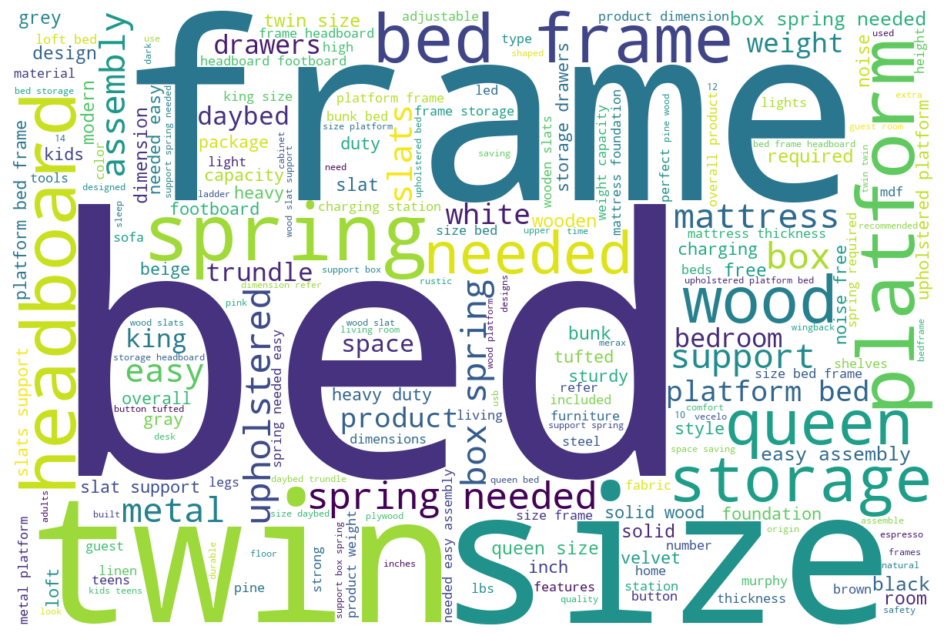

Top 50 keywords/ngrams:
              keyword   count
0                 bed  278178
1               frame  179576
2                size  131460
3                twin  116547
4              spring  109890
5            platform  105856
6           headboard   97764
7           bed frame   91460
8                wood   85879
9             storage   82292
10              queen   81203
11             needed   77839
12      spring needed   75151
13                box   69973
14        upholstered   68647
15           mattress   61728
16              metal   60686
17         box spring   59721
18            support   58894
19           assembly   58449
20              slats   52533
21               easy   51736
22       platform bed   51444
23              white   50618
24            product   48284
25             weight   45727
26            drawers   44278
27            bedroom   44261
28               king   42889
29             daybed   42464
30            trundle   41762
31              

In [57]:
def collect_texts(df):
    """title, keywords_list, description만 합쳐서 하나의 문자열로 반환"""
    def _norm_list(x):
        if isinstance(x, list):
            return x
        if isinstance(x, str):
            return [t.strip() for t in x.split(",") if t.strip()]
        return []
    
    texts = []
    for _, row in df.iterrows():
        title = str(row.get("title") or "")
        desc = str(row.get("description") or "")
        kw_list = _norm_list(row.get("keywords_list"))
        kw = " ".join(map(str, kw_list))
        txt = " ".join([title, kw, desc]).lower()
        txt = re.sub(r"[^a-z0-9 ]+", " ", txt)
        txt = re.sub(r"\s+", " ", txt).strip()
        texts.append(txt)
    return texts


def make_wordcloud(df, ngram_range=(1,3), max_words=200, top_n=30):
    texts = collect_texts(df)
    
    # 단어/구 빈도 계산
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(texts)
    freqs = dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1))
    
    # ===== 워드 클라우드 =====
    wc = WordCloud(width=1200, height=800,
                   background_color="white",
                   colormap="viridis",
                   max_words=max_words).generate_from_frequencies(freqs)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()
    
    # ===== 키워드 + 빈도수 출력 =====
    freq_df = pd.DataFrame(freqs.items(), columns=["keyword", "count"])
    freq_df = freq_df.sort_values("count", ascending=False).reset_index(drop=True)
    
    print(f"Top {top_n} keywords/ngrams:")
    print(freq_df.head(top_n))
    
    return freq_df


# 사용 예시
# df = pd.read_csv("your_data.csv")
freq_table = make_wordcloud(df, ngram_range=(1,3), max_words=200, top_n=50)

In [59]:
def collect_texts(df):
    """title, keywords_list, description만 합쳐서 하나의 문자열로 반환"""
    def _norm_list(x):
        if isinstance(x, list):
            return x
        if isinstance(x, str):
            return [t.strip() for t in x.split(",") if t.strip()]
        return []
    
    texts = []
    for _, row in df.iterrows():
        title = str(row.get("title") or "")
        desc = str(row.get("description") or "")
        kw_list = _norm_list(row.get("keywords_list"))
        kw = " ".join(map(str, kw_list))
        txt = " ".join([title, kw, desc]).lower()
        txt = re.sub(r"[^a-z0-9 ]+", " ", txt)
        txt = re.sub(r"\s+", " ", txt).strip()
        texts.append(txt)
    return texts


def keyword_frequencies(df, ngram_range=(1,3)):
    texts = collect_texts(df)
    
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(texts)
    freqs = dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1))
    
    # 모든 키워드와 빈도수 DataFrame 생성
    freq_df = pd.DataFrame(freqs.items(), columns=["keyword", "count"])
    freq_df = freq_df.sort_values("count", ascending=False).reset_index(drop=True)
    return freq_df


# 사용 예시
# df = pd.read_csv("your_data.csv")
freq_table = keyword_frequencies(df, ngram_range=(1,3))
print(freq_table)

                          keyword   count
0                             bed  278178
1                           frame  179576
2                            size  131460
3                            twin  116547
4                          spring  109890
...                           ...     ...
1156917  provides minimal partner       1
1156918          provides minimal       1
1156919      provides memory foam       1
1156920           provides memory       1
1156921        zzz stylish daybed       1

[1156922 rows x 2 columns]


In [61]:
freq_table.to_csv('non_mattress_keywords.csv')